In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file == 'bank-full.csv':
            print(os.path.join(root, file))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive')

['Classroom',
 'Screenshot_20230203_193428.jpg',
 'Screenshot_20230208_103804.jpg',
 'REZAUL KARIM_AA200.11.pptx',
 'cse lab',
 'Cse lab',
 'rezaul karim.docx',
 '231016812.docx',
 'Cse lab report.docx',
 'Doc1.docx',
 'REZAUL KARIM.docx',
 'labb.docx',
 'Doc1 (1).docx',
 '231016812.pdf',
 'Rezaul karim.docx',
 'public class MyClass {.gdoc',
 'Untitled document (12).gdoc',
 'Classwork_lab4.gdoc',
 'Untitled document (11).gdoc',
 'IMG_2005.HEIC',
 'Untitled document (10).gdoc',
 'HighlightedRosen6E_31-01-2021.pdf',
 'Untitled document (9).gdoc',
 'Untitled document (8).gdoc',
 'Untitled document (7).gdoc',
 'Untitled document (6).gdoc',
 'CamScanner 05-19-2024 12.45.jpg',
 'Alg lab 1 2 3.gdoc',
 'Screenshot_20240907_233739.jpg',
 'IMG_20240907_234202.jpg',
 'CamScanner 10-04-2024 23.08.jpg',
 'fcfs',
 'Untitled document (5).gdoc',
 'CSE 316_exp2.gdoc',
 'Untitled document (4).gdoc',
 'IMG_20241203_000429.jpg',
 'IMG_20250121_021504.jpg',
 'Untitled document (3).gdoc',
 'wewq.pkt',
 'LAB

In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/bank-data.zip'
extract_path = '/content/drive/MyDrive/bank-data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
os.listdir('/content/drive/MyDrive/bank-data')

['bank-data', '__MACOSX']

In [ ]:
os.listdir('/content/drive/MyDrive/bank-data/bank-data')

['.DS_Store', 'bank-full.csv']

In [ ]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/bank-data/bank-data/bank-full.csv',
    sep=';'
)

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
df['y'].unique()

array(['no', 'yes'], dtype=object)

In [ ]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [ ]:
y = df['y'].values.astype(np.float32)
print("Positive class ratio:", y.mean())

Positive class ratio: nan


In [ ]:
print("Positive class ratio:", y.mean())

Positive class ratio: nan


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/drive/MyDrive/bank-data/bank-data/bank-full.csv', sep=';')

df.columns = df.columns.str.strip()

df['pdays'] = df['pdays'].replace(-1, np.nan)
df = df.replace("unknown", np.nan)

df['job'] = df['job'].fillna(df['job'].mode()[0])
df['education'] = df['education'].fillna(df['education'].mode()[0])
df['contact'] = df['contact'].fillna("none")
df['poutcome'] = df['poutcome'].fillna("none")

df['balance'] = np.clip(df['balance'], -5000, 20000)
df['campaign'] = np.clip(df['campaign'], 1, 10)
df['previous'] = np.clip(df['previous'], 0, 20)

df = df.drop('duration', axis=1)

df['y'] = df['y'].map({'yes': 1, 'no': 0})

df = pd.get_dummies(df, drop_first=True)

X = df.drop('y', axis=1).values.astype(np.float32)
y = df['y'].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
print("Positive class ratio:", y.mean())

Positive class ratio: 0.11698481


In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
imputer = SimpleImputer(strategy='most_frequent')

X_train_fixed = imputer.fit_transform(X_train)
X_test_fixed  = imputer.transform(X_test)

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_fixed, y_train)

y_pred_lr = log_model.predict(X_test_fixed)

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Accuracy: 0.8926241291606768


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8950569501271702


In [ ]:
from sklearn.metrics import roc_auc_score

y_pred_proba = rf.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

ROC-AUC: 0.7897039936648702


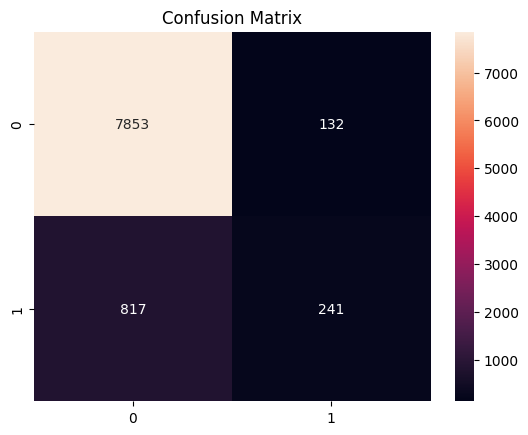

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=df.drop('y', axis=1).columns
)

print(feature_importance.sort_values(ascending=False).head(10))

balance                0.186905
age                    0.155975
day                    0.134370
campaign               0.061579
pdays                  0.057211
poutcome_success       0.053777
previous               0.026108
housing_yes            0.020644
education_secondary    0.018080
job_technician         0.015196
dtype: float64


In [ ]:
import torch

torch.save(log_model, "logistic_model.pkl")
print("Logistic model saved successfully!")

Logistic model saved successfully!
